# LSTM (장기 의존성 학습 모델)
- RNN 구조에서 발생하는 문제를 해결하기 위해 구조를 변경한 모델
- 기존의 RNN은 학습의 횟수가 증가
    - 반복 학습을 하면서 가중치의 변화량이 0에 가까워짐을 의미
    - 손실 함수 -> tanh -> 반복적으로 tanh() 함수를 실행하게 되면 변화량 0
    - LSTM은 반복 학습을 하면서 과거의 기억 중 장기 기억과 단기 기억으로 나눠주는 역할
        - 반복 학습을 하면서 tanh() 중복적으로 실행이 되면 기울기 변화량 줄어듬.
        - 장기 기억은 tanh() 함수를 실행하지 않고 -> 가중치의 변화를 계속 주겠다.
        - 셀이라는 공간에 장기 기억 정보를 전달
        - 게이트로 정도를 선택적으로 보관, 삭제

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [203]:
# 데이터로드
df = pd.read_csv("../data_git/csv/AAPL.csv")

In [204]:
type(df['Date'][0])

str

In [205]:
# Date 컬럼의 dtype을 시계열 데이터로 변환
# 문자형 데이터를 시계열 데이터로 변환 -> 
df['Date'] = pd.to_datetime(
    df['Date']
)

In [206]:
type(df['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [207]:
# 특정 컬럼 선택
df = df[['Date', 'Adj Close', 'Volume']]
# 결측치가 포함되어있는 행을 모두 제거
df.dropna(axis=0, inplace=True)

In [208]:
# 독립 데이터, 종속 데이터를 생성
X_all = df[['Adj Close', 'Volume']]
Y_all = df[['Adj Close']]

In [209]:
# 데이터를 8:2의 비율로 나눠준다
split_idx = int(len(df)* 0.8)
X_train, X_test = X_all[ : split_idx], X_all[split_idx : ]
Y_train, Y_test = Y_all[ : split_idx], Y_all[split_idx : ]
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(7770, 2) (1943, 2)
(7770, 1) (1943, 1)


In [210]:
# 초기 설정 값
# 시계열 데이터의 구간 (과거 데이터의 개수)
window = 60
# 학습 루프에서 루프의 수
epochs = 20
# 학습 데이터의 배치의 개수
x_batch = 64
# optimizer lr 값 (학습율)
lr = 0.001
# 은닉 층의 뉴런의 개수
hidden_cnt = 64
# 랜덤의 일반화
torch.manual_seed(42)
# 은닉층, 셀 사용 여부
head_type = 'h'

In [211]:
class WindowDataset(Dataset):
    # 입력 데이터와 타깃 데이터를 받아서
    # 구간의 수만큼 입력데이터를 잘라주고
    # 해당구간 바로 다음 행의 타깃 데이터를 생성
    # 구간의 데이터와 다음행의 타깃 데이터를 되돌려준다
    # DataLoader 클래스에서 사용하기 위함
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        # n의 값은 구간의 데이터의 시작 지점의 최대값
        self.n = len(_x) - _window
    
    def __len__(self):
        # window의 수치가 x의 길이보다 큰 경우에는 1을 되돌려준다.
        return max(self.n, 1)
    def __getitem__(self, idx):
        # idx: 구간의 시작 지점 -> 최대값은 self.n
        # idx부터 idx+window-1지점까지의 데이터 -> (window, 2)
        x_window = self.x[idx : idx + self.window]
        # idx+window 위치의 데이터 -> 단일값 생성
        y_next = self.y[idx + self.window]
        # tensor 형의 변환
        x_tensor = torch.from_numpy(x_window)
        y_tensor = torch.from_numpy(y_next)
        
        return x_tensor, y_tensor

In [212]:
# 데이터들 스케일링 -> MinMaxScaler
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(Y_train)

X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)
Y_train = y_scaler.transform(Y_train)
Y_test = y_scaler.transform(Y_test)

In [213]:
# 객체를 생성하고 get item 함수를 실행시키면 
# 해당 구간 다음 행의 종가 데이터를 되돌려주는 class
train_ds = WindowDataset(X_train, Y_train, window)
test_ds = WindowDataset(X_test, Y_test, window)

In [214]:
# Dataloader -> WindowDataset class를 이용하여
# ds_data에서 len()함수를 이용하여 해당 구간에서 가장 마지막에 사용 가능한 시간
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=x_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)

In [215]:
# for x, y in train_dl:
#     print("구간 데이터 : ", x)
#     print("다음날의 종가 : ", y)

In [216]:
# LSTM 모델 정의

class LSTMReg(nn.Module):
    # h: 마지막의 은닉층의 데이터를 이용 (RNN -> 기억소실, LSTM -> 장기적인 기억)
    # c: 셀의 데이터를 이용
    # h_c: 은닉층 + 셀의 데이터를 이용
    def __init__(self, input_size, hidden_size, num_layers = 1, dropout = 0.0, bidirectional = False, head_type='h'):
        super().__init__()
        # lstm 기본 설정
        # batch_first 매개변수
            # 기본값은 False
            # RNN, LSTM의 기본적인 입력값의 형태는 (구간의 수, 배치의 개수, 피쳐의 수)
            # True로 변경시 (배치의 개수, 구간의 수, 피쳐의 수)의 형태로 입력값을 확인
            # DataLoader에서 반환하는 데이터의 형태는 (배치의 개수, 구간의 수, 피쳐의 수)이기 때문에 해당 매개변수를 True로 변경해야 함
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first = True
        )
        # bidirectional 이 True인 경우 차원의 개수 * 2
        out_dim = hidden_size * (2 if bidirectional else 1) 
        # head_type은 은닉층만 사용 -> 차원의 개수 * 1
        if head_type in ['h', 'c']:
            head_in = out_dim
        elif head_type == 'h_c':
            head_in = out_dim * 2
        else:
            print('head_type Error')
        self.head = nn.Sequential(
            nn.Linear(head_in, 1)
        )
        self.head_type = head_type
    # 순전파 함수
    def forward(self, x):
        # 순전파의 예측 결과 값
        out, (h_n, c_n) = self.lstm(x)
        # 은닉층 중 마지막 은닉층을 저장
        h_last = h_n[-1]
        # 마지막 셀 저장
        c_last = torch.tanh(c_n[-1])

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type =='h_c':
            feat = torch.cat([h_last, c_last], dim = -1)
        
        return self.head(feat)

In [217]:
model = LSTMReg(input_size=2, hidden_size=hidden_cnt, head_type=head_type)
model

LSTMReg(
  (lstm): LSTM(2, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [218]:
# 손실함수 -> 회귀모델(MSELoss) : 정답이 존재하지만 정확히 맞추기 쉽지 않다 -> 오차
        # -> 분류모델(CrossEntropyLoss) : 정답을 정확하게 맞췄는가? -> 이진 분류, 다중 분류
criterion = nn.MSELoss()
# 가중치의 변화 (학습에 대한 가중을 변화)
# SGD(단순 경사 하강)
# Adam(학습율에 따른 동적인 가중치 변화)
optimizer = optim.Adam(model.parameters(), lr = lr)

In [219]:
# Loss를 구하는 함수를 생성 -> torch의 모델은 자동 미분이 활성화. 비활성화로 바꾸고 작업
# Loss의 값을 구하는 경우 루프가 끝나고 지정하기 때문에 미분 계산이 무의미(비활성화)
# 계산이 비활성화 되기 때문에 메모리 효율 증가, 속도 빨라진다
@torch.no_grad()
def evaluate_mse(dl):
    # eval(): 해당 모델을 평가 모드로 변환
    model.eval()
    # 총 로스, 총 개수 초기 값 지정
    total_loss = 0.0
    total_n = 0
    # DataLoader 를 매개변수로 입력을 받아서 사용 -> batch_size의 개수만큼 데이터가 존재
    for x, y in dl:
        # x -> 독립변수(문제)
        # y -> 종속변수(답)
        # torch에서의 계산은 float 형태에서 계산
        x = x.float()
        y = y.float()
        # 예측
        pred = model(x)
        # 예측 값과 실제 값의 loss를 확인
        loss = criterion(pred, y)   # 평균 손실 데이터
        # 평균 손실 * y의 크기 -> 총 손실을 누적합
        total_loss += loss.item() * y.size(0)
        # 총 개수를 누적합
        total_n += y.size(0)
    # 함수에서 되돌려주는 결과 값 -> total_loss, total_n
    # dl의 batch_size가 0이라면 -> 0/0 -> Error발생 -> 분모는 max()이용
    return total_loss / max(total_n, 1)



In [220]:
# 반복학습 루프(반복학습) : 순전파 -> 손실 -> 역전파 -> 옵티마이저 : 하나의 스텝
# loss 값의 변화를 저장
train_history = []
test_history = []

# 반복 횟수에 따른 반복문이 생성
for epoch in range(epochs):
    # 모델의 학습 모드 변환
    model.train()
    # 총 손실에 대한 평균을 구하기 위해서 총 로스, 총 개수의 초기값을 설정
    tot_loss = 0.0
    tot_n = 0
    # train인 DataLoader를 이용하여 반복문을 실행
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        # 학습 루프가 반복적으로 실행이 되기 때문에 미분의 값을 초기화
        optimizer.zero_grad()
        # 모델에 학습 데이터를 학습하여 예측
        pred = model(x)
        loss = criterion(pred, y)
        # 역전
        loss.backward()
        # 기울기 너무 급격학 변화해서 폭주하는 상황을 방지
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        # 총 손실의 누적합
        tot_loss += loss.item() * y.size(0)
        # 총 개수의 누적합
        tot_n += y.size(0)

    # train 데이터에 총 loss의 평균
    train_loss = tot_loss / max(tot_n, 1)
    # test 데이터에 총 loss의 평균
    test_loss = evaluate_mse(test_dl)
    # loss의 내역을 저장
    train_history.append(train_loss)
    test_history.append(test_loss)
    print(f"Epoch : {epoch+1}, train_mse : {round(train_loss, 4)}, test_mse : {round(test_loss, 4)}")

Epoch : 1, train_mse : 0.0132, test_mse : 1.1331
Epoch : 2, train_mse : 0.0002, test_mse : 1.027
Epoch : 3, train_mse : 0.0001, test_mse : 0.9453
Epoch : 4, train_mse : 0.0001, test_mse : 0.8157
Epoch : 5, train_mse : 0.0001, test_mse : 0.7549
Epoch : 6, train_mse : 0.0001, test_mse : 0.6838
Epoch : 7, train_mse : 0.0001, test_mse : 0.6056
Epoch : 8, train_mse : 0.0001, test_mse : 0.5535
Epoch : 9, train_mse : 0.0001, test_mse : 0.49
Epoch : 10, train_mse : 0.0001, test_mse : 0.4392
Epoch : 11, train_mse : 0.0001, test_mse : 0.4238
Epoch : 12, train_mse : 0.0001, test_mse : 0.362
Epoch : 13, train_mse : 0.0001, test_mse : 0.3589
Epoch : 14, train_mse : 0.0001, test_mse : 0.322
Epoch : 15, train_mse : 0.0001, test_mse : 0.2872
Epoch : 16, train_mse : 0.0001, test_mse : 0.266
Epoch : 17, train_mse : 0.0001, test_mse : 0.2491
Epoch : 18, train_mse : 0.0001, test_mse : 0.2244
Epoch : 19, train_mse : 0.0, test_mse : 0.2006
Epoch : 20, train_mse : 0.0001, test_mse : 0.1913


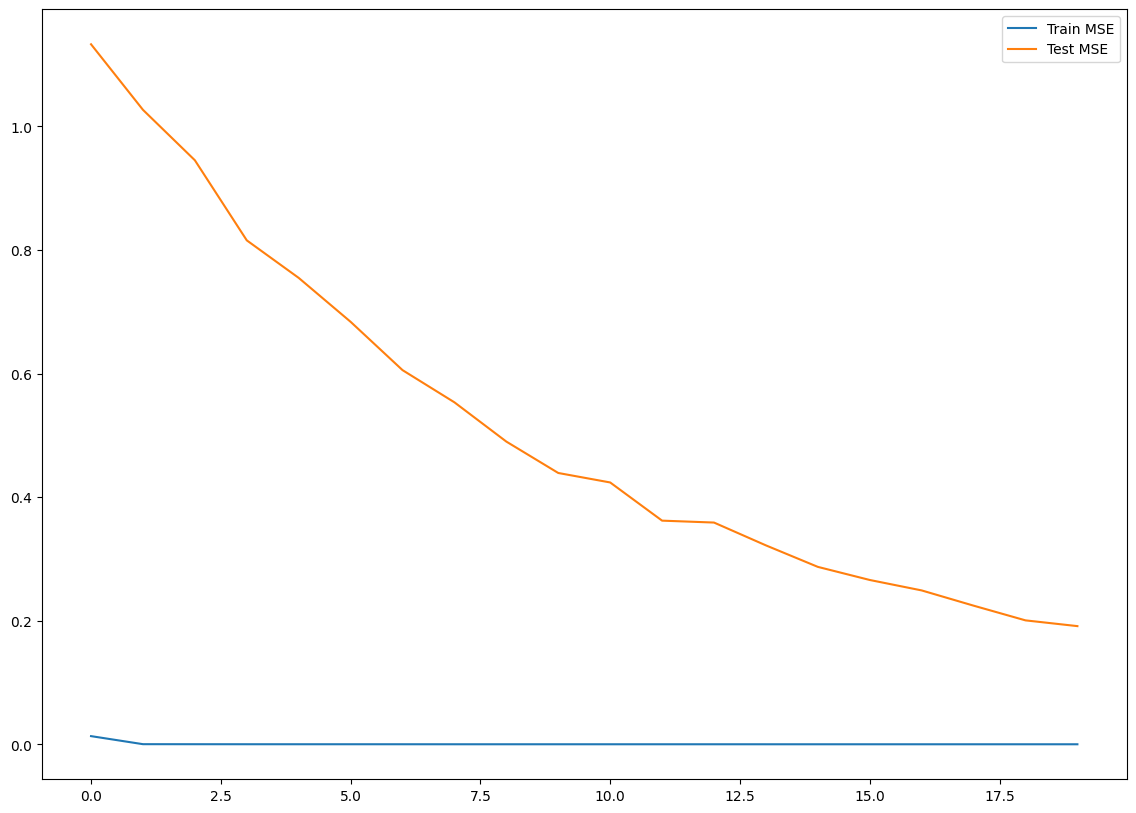

In [221]:
# train_mse와 test_mse 의 변화량을 그래프 확인
plt.figure(figsize = (14, 10))
plt.plot(train_history, label = 'Train MSE')
plt.plot(test_history, label = 'Test MSE')
plt.legend()
plt.show()

In [222]:
# 검증 예측, 실제 값을 그래프로 시각화
model.eval()
# 예측 값과 실제 값을 1차원 리스트로
preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x).cpu()
        preds.append(pred)
        trues.append(y)

preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

# preds, trues는 아직 스케일링이 되어있는 상태
# 데이터의 역변환
preds_origin = y_scaler.inverse_transform(preds.reshape(-1, 1)).squeeze()
trues_origin = y_scaler.inverse_transform(trues.reshape(-1, 1)).squeeze()

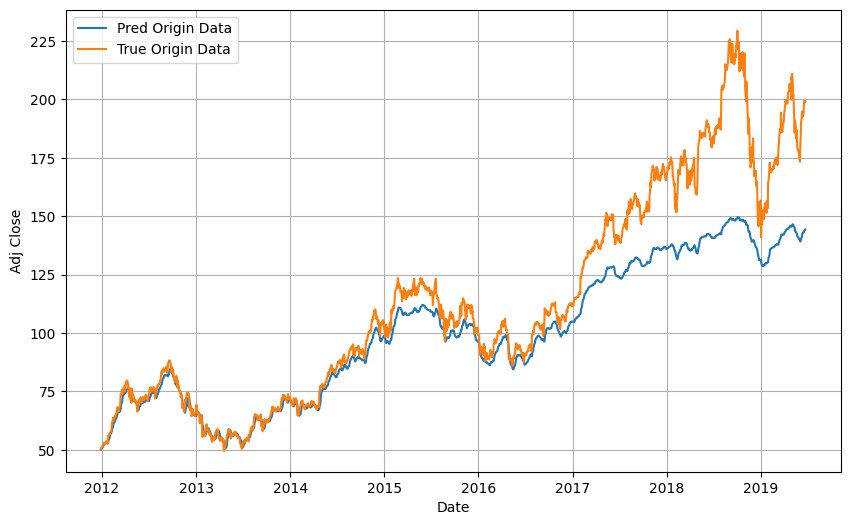

In [223]:
plt.figure(figsize=(10, 6))
# x축에서 사용할 시간 데이터를 로드
x_data = df['Date'].values[split_idx + window : ]
plt.plot(x_data, preds_origin, label = 'Pred Origin Data')
plt.plot(x_data, trues_origin, label = 'True Origin Data')

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.show()

In [224]:
# 해당 데이터셋에서 존재하지 않는 다음날의 수정 종가를 확인 (미래 예측)
# 데이터셋에서 영업일 기준 60일치 마지막 부분의 데이터를 필터링
# feat_last = df[['Adj Close', 'Volume']].astype('float').values[-window :]
feat_last = df[['Adj Close', 'Volume']].tail(window).values
# 스케일링 -> 스케일러 선택(x_scaler)
feat_last_sc = x_scaler.transform(feat_last)
feat_last_sc

/Users/eunseo/Documents/data_boot/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[3.66510392, 0.01251537],
       [3.69001525, 0.01483227],
       [3.74370015, 0.01208503],
       [3.76938408, 0.01235786],
       [3.77594995, 0.01011669],
       [3.80124729, 0.00979988],
       [3.861112  , 0.01376476],
       [3.84952525, 0.01909423],
       [3.87115349, 0.01150802],
       [3.838904  , 0.01107973],
       [3.83735903, 0.01477767],
       [3.84431121, 0.00926621],
       [3.84469751, 0.01366487],
       [3.91962464, 0.01539549],
       [3.93372183, 0.01285595],
       [3.94666009, 0.010292  ],
       [4.00362776, 0.01238546],
       [3.9974485 , 0.00926836],
       [3.9611436 , 0.00980883],
       [3.94221866, 0.00986592],
       [3.94820504, 0.01178262],
       [3.87211928, 0.02489818],
       [4.06233383, 0.03475898],
       [4.03587755, 0.01706093],
       [4.0860865 , 0.0110752 ],
       [4.02293901, 0.01730178],
       [3.91441058, 0.020709  ],
       [3.91518292, 0.01401155],
       [3.87308477, 0.01863085],
       [3.81938688, 0.02202701],
       [3.

In [230]:
import numpy as np

In [235]:
# model에 데이터를 대입하여 예측을 만들기 위해서는 LSTM에서 입력으로 사용이 될 데이터셋으로 변환
# tensor 형 데이터로 변환 -> (batch_size, window, n_features) 크기
# (1, 60, 2)
x_input = torch.from_numpy(feat_last_sc.astype(np.float32)).unsqueeze(0)

In [236]:
# 모델을 평가모드로 변환
model.eval
with torch.no_grad():
    y_pred_sc = model(x_input).numpy()

In [238]:
y_pred_sc

array([[2.797647]], dtype=float32)

In [239]:
# 원본의 데이터셋으로 역변환 -> 스케일링이 된 수정 종가 데이터를 원본의 형태로 변환
# 스케일러 선택은? -> y_scaler
last_pred = y_scaler.inverse_transform(y_pred_sc)[0, 0]
last_pred

np.float32(144.47359)